## Why Initialization Matters

### Why can't weights all start at zero?
- If all weights are initialized to zero, neurons in the same layer become symmetric. They produce identical outputs, receive identical gradients during backpropagation, and remain identical after every update. As a result, the network cannot learn different features, greatly reducing its representational capacity.

### What problem would identical initialization cause?
- Identical initialization causes a symmetry problem. Regardless of the initial value, neurons compute the same outputs and receive the same gradient updates. Since they always update identically, they never specialize to learn different features.

### Why use random initialization?
- Random initialization breaks symmetry between neurons. Because neurons start with different weights, they produce different outputs and receive different gradient updates. Over time, each neuron learns different features, allowing the network to represent complex patterns.

## Inspect Default Initialization

In [ ]:
import torch

model = torch.nn.Linear(10, 5)

print(model.weight, model.weight.shape)
print(model.bias, model.bias.shape)

Parameter containing:
tensor([[-0.2611,  0.0420, -0.1185, -0.2607,  0.2858,  0.2322,  0.1804,  0.1154,
          0.1180,  0.2191],
        [ 0.0852, -0.1059,  0.2759,  0.1995,  0.0681,  0.1298, -0.2164, -0.0013,
         -0.2093, -0.0772],
        [ 0.1474,  0.1645,  0.0402, -0.1604,  0.1710, -0.1874, -0.0518, -0.0678,
          0.0711,  0.2921],
        [-0.1898,  0.1448, -0.2536, -0.1445, -0.2916,  0.2633,  0.0686, -0.2689,
         -0.2914,  0.0488],
        [-0.0414, -0.0871,  0.0972, -0.1344,  0.1975, -0.1241, -0.0406,  0.2810,
         -0.2500, -0.2403]], requires_grad=True) torch.Size([5, 10])
Parameter containing:
tensor([-0.0993,  0.0922,  0.0514,  0.1036,  0.1911], requires_grad=True) torch.Size([5])


### Are weights large or small?
- The weights are initialized with relatively small random values centered around zero. They are typically both positive and negative to avoid large activations at the start of training.

### Why?
- Weights are initialized with small random values so that activations remain within a reasonable range during the forward pass. Large initial weights can produce very large activations, leading to unstable optimization, exploding or vanishing gradients, and slower or failed convergence.

## Zero Initialization Experiment

In [ ]:
from sklearn.datasets import load_wine

data = load_wine()
X = data.data
y = data.target

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

import torch

x_train_scaled = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_scaled = torch.tensor(x_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import Dataset, DataLoader

class SimpleDataset(Dataset):
    def __init__(self):
        super().__init__()
        self.X = x_train_scaled
        self.y = y_train
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

dataset = SimpleDataset()

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
class WineClassifierModelReLU(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.activation_fn = torch.nn.ReLU()
        self.fc1 = torch.nn.Linear(13, 8)
        self.fc2 = torch.nn.Linear(8, 4)
        self.fc3 = torch.nn.Linear(4, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.activation_fn(x)
        x = self.fc2(x)
        x = self.activation_fn(x)
        x = self.fc3(x)
        
        return x
    
class WineClassifierModelSigmoid(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.activation_fn = torch.nn.Sigmoid()
        self.fc1 = torch.nn.Linear(13, 8)
        self.fc2 = torch.nn.Linear(8, 4)
        self.fc3 = torch.nn.Linear(4, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.activation_fn(x)
        x = self.fc2(x)
        x = self.activation_fn(x)
        x = self.fc3(x)
        
        return x
    
class WineClassifierModelTanh(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.activation_fn = torch.nn.Tanh()
        self.fc1 = torch.nn.Linear(13, 8)
        self.fc2 = torch.nn.Linear(8, 4)
        self.fc3 = torch.nn.Linear(4, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.activation_fn(x)
        x = self.fc2(x)
        x = self.activation_fn(x)
        x = self.fc3(x)
        
        return x

### Creating model training loop and packing it into function.

In [ ]:
from typing import List, Tuple

def train_model(model, loader, optimizer, loss_fn, epochs=100)  -> Tuple[List, List]:

    train_losses = []
    validation_losses = []

    for epoch in range(epochs):
        train_loss = 0
        validation_loss = 0
        
        model.train()
        
        for x_batch, y_batch in loader:
            
            pred = model(x_batch)
            
            loss = loss_fn(pred, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        model.eval()
        
        with torch.no_grad():
            
            pred = model(x_test_scaled)
            
            validation_loss = loss_fn(pred, y_test)
        
        train_loss = train_loss / len(loader)
        
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        
    print("training complete")
        
    return validation_losses, train_losses

### Making a function to plot train and validation losses

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val_loss_curve(train_losses, validation_losses, title):
    
    train_losses = np.array(train_losses)
    validation_losses = np.array(validation_losses)

    train_min_idx = np.argmin(train_losses)
    val_min_idx = np.argmin(validation_losses)

    plt.plot(validation_losses, label='Validation Loss')
    plt.plot(train_losses, label="Training Loss")

    plt.scatter(train_min_idx, train_losses[train_min_idx])
    plt.scatter(val_min_idx, validation_losses[val_min_idx])

    plt.annotate(
        f"Epoch {val_min_idx}\n{validation_losses[val_min_idx]:.4f}",
        (float(val_min_idx), validation_losses[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    plt.annotate(
        f"Epoch {train_min_idx}\n{train_losses[train_min_idx]:.4f}",
        (float(train_min_idx), train_losses[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    plt.legend()
    plt.title(title)
    plt.show()

### Training Model with all weights initialized as Zero and Displaying training vs validation curve

In [ ]:
torch.manual_seed(42)

training complete


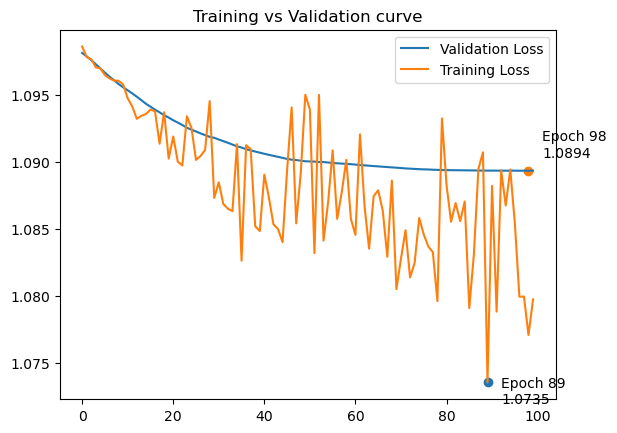

In [ ]:
model = WineClassifierModelReLU()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Setting all weights to Zero

for param in model.parameters():
    torch.nn.init.constant_(param, 0)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve")

### Does learning occur?
- Model learns very little as seen in training vs validation curve. Validation loss drops form 1.098 to 1.0910 which is small enough that the model is not learning useful representations.

### Why or why not?
- Learning is extremely limited because all neurons begin with identical weights. During forward propagation they produce identical outputs, and during backpropagation they receive identical gradients. Since every update is the same, the symmetry is never broken, preventing neurons from learning different features. As a result, the model behaves like it has far fewer effective neurons, leading to poor optimization and only minimal reduction in loss.

## Large Weight Initialization

### Training Model with all weights initialized as large values and Displaying training vs validation curve

training complete


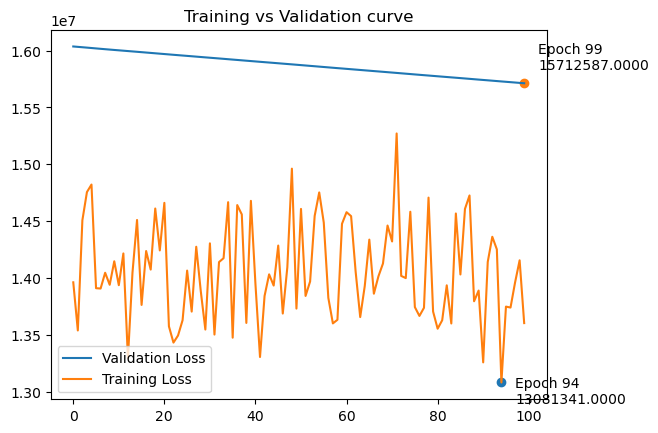

In [ ]:
model = WineClassifierModelReLU()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Setting all weights to some Large value

for param in model.parameters():
    torch.nn.init.normal_(param, 10, 100)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve")

### What happens to loss?
- Large initial weights produce very large weighted sums, resulting in large activations or logits. If these predictions are far from the target values, the loss becomes large. Even when the loss is not extremely large, oversized activations can still make optimization unstable by producing poor gradient behavior.

### Why can large weights make optimization unstable?
- Large initial weights produce large activations. These activations may saturate functions such as sigmoid or tanh, causing gradients to vanish, or they may lead to exploding values in deeper networks. Both situations result in unstable optimization because parameter updates become ineffective or excessively large.

## Xavier Initialization

training complete


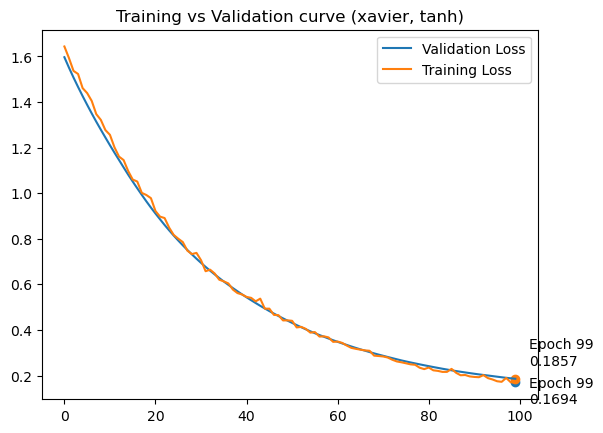

In [ ]:
def init_weights(module):
    
    if isinstance(module, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        torch.nn.init.zeros_(module.bias)        

model = WineClassifierModelTanh()

model.apply(init_weights)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve (xavier, tanh)")

### What problem does Xavier solve?
- Xavier initialization chooses the initial weights based on the number of input and output connections (fan_in and fan_out). This keeps the variance of activations approximately constant across layers, preventing signals from exploding or vanishing during the early stages of training and making optimization more stable.

### Which activation functions is it designed for?
- Xavier initialization was derived for activation functions such as sigmoid and tanh because it aims to preserve the variance (spread) of activations across layers. ReLU changes the variance by setting many activations to zero, so Xavier no longer preserves the signal as intended. "He" initialization compensates for this behavior and is therefore generally preferred with ReLU.

### Why is Sigmoid performing worse.
- Sigmoid performs worse because large positive or negative pre-activations (Wx+b) produce derivatives close to zero. During backpropagation, these tiny derivatives multiply the incoming gradients, causing the learning signal to shrink before it reaches earlier layers. As a result, the corresponding weights receive extremely small updates and learn very slowly.

## He Initialization

training complete


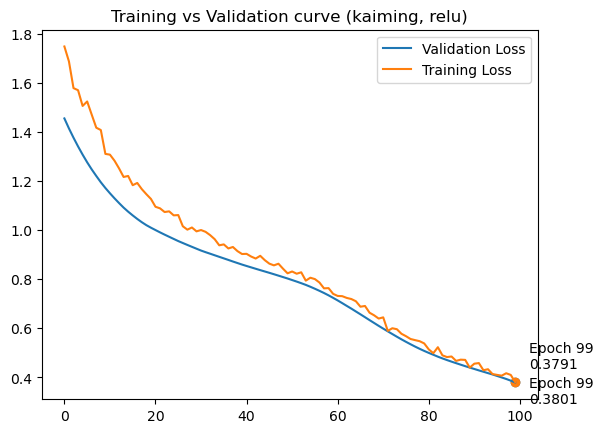

In [ ]:
def init_weights(module):
    
    if isinstance(module, torch.nn.Linear):
        torch.nn.init.kaiming_uniform_(module.weight)
        torch.nn.init.zeros_(module.bias)

model = WineClassifierModelReLU()

model.apply(init_weights)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve (kaiming, relu)")

### Why is He initialization recommended with ReLU?
- He initialization is recommended with ReLU because ReLU sets all negative pre-activations (Wx+b) to zero, reducing the variance of activations passed to the next layer. He initialization starts with a larger weight variance so that after ReLU removes roughly half of the signal, the remaining activations still have an appropriate variance for stable gradient flow.

### How does it differ from Xavier?
- Xavier initialization assumes the activation function approximately preserves the variance of the signal, so it chooses the initial weight variance to keep activations stable across layers. He initialization recognizes that ReLU reduces the activation variance by setting many values to zero, so it initializes weights with a larger variance to compensate for that expected loss.

## SGD vs Adam

training complete


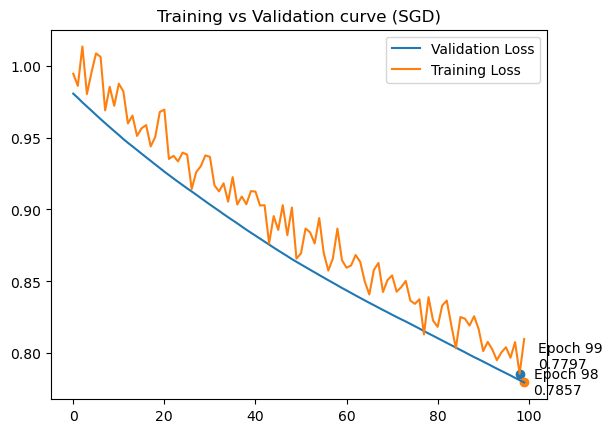

In [ ]:
def init_weights(module):
    
    if isinstance(module, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        torch.nn.init.zeros_(module.bias)        

model = WineClassifierModelReLU()

model.apply(init_weights)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve (SGD)")

training complete


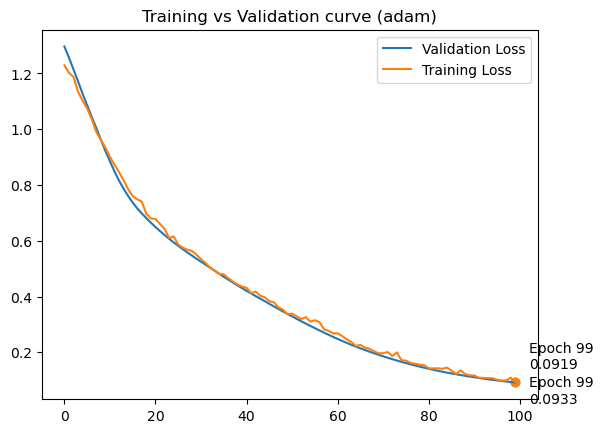

In [ ]:
def init_weights(module):
    
    if isinstance(module, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        torch.nn.init.zeros_(module.bias)        

model = WineClassifierModelReLU()

model.apply(init_weights)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve (adam)")

### Which converges faster?
- Model which is optimized using Adam converges fast because it changes learning rate based on gradient it prevent large parameter update to parameters with large gradient and helps parameters with small gradient thus it converges faster. Adam also keeps estimates of the first moment (moving average of gradients) the second moment (moving average of squared gradients)

### Does faster always mean better?
- Adam often reaches a low training loss faster because it adapts the learning rate for each parameter using estimates of the first and second moments of the gradients. However, faster convergence does not guarantee better generalization. In some problems, SGD with momentum converges more slowly but produces a model that performs better on unseen data because it may find flatter minima that generalize better.

## Learning Rate Experiment

### 0.1

training complete


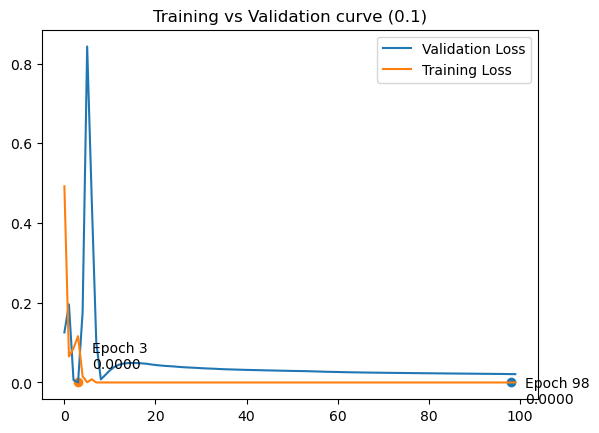

In [ ]:
def init_weights(module):
    
    if isinstance(module, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        torch.nn.init.zeros_(module.bias)        

model = WineClassifierModelReLU()

model.apply(init_weights)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.1
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve (0.1)")

### 0.01

training complete


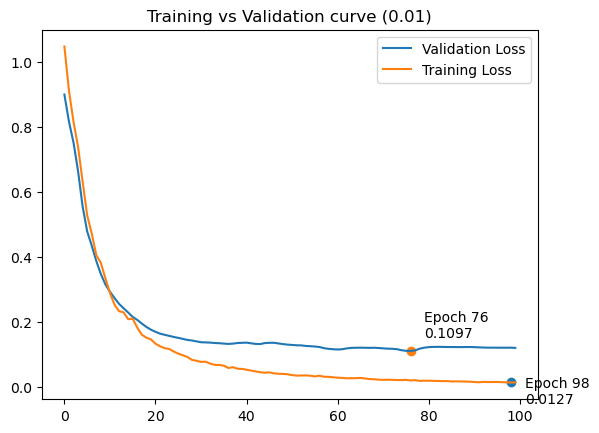

In [ ]:
def init_weights(module):
    
    if isinstance(module, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        torch.nn.init.zeros_(module.bias)        

model = WineClassifierModelReLU()

model.apply(init_weights)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve (0.01)")

### 0.001

training complete


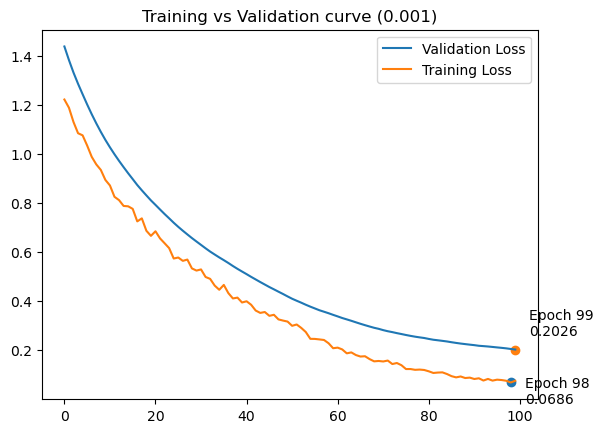

In [ ]:
def init_weights(module):
    
    if isinstance(module, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(module.weight)
        torch.nn.init.zeros_(module.bias)        

model = WineClassifierModelReLU()

model.apply(init_weights)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

plot_train_val_loss_curve(train_losses, validation_losses, "Training vs Validation curve (0.001)")

### Which diverges?
- None of them diverges.

### Which converges slowly?
- 0.001 converges slowly. 

### Which provides stable learning?
- 0.001 provides stable learning.

## Optimizer State

### Why does Adam require more memory than SGD?
- Because it keeps estimates of the first moment (moving average of gradients) the second moment (moving average of squared gradients) to adjusts the effective learning rate for each parameter using estimates of the first and second moments of the gradients.

### What additional information does it keep?
- It keeps two extra tenser of every parameters in model:
    - First moment (an exponential moving average of past gradients) 
    - Second moment (an exponential moving average of squared gradients).

## Practical Reflection

If a model is not learning:

Should you immediately increase depth?

Or should you first inspect:

- initialization
- optimizer
- learning rate

### Why?

- If a model is not learning, I would first inspect initialization, the optimizer, learning rate, gradients, and the training pipeline before increasing model depth. A failure to learn is often caused by optimization issues rather than insufficient model capacity. Increasing depth without diagnosing these problems can increase computational cost, make optimization more difficult, and even worsen issues such as vanishing gradients or overfitting without improving performance.